In [2]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from numpy import random
from utils import load_bci_iv2a, EEGNet
from topoplot_python import make_pos_from_names, plot_spatial_filters
from tensorflow.keras import utils

In [3]:
N = 22 # number of rows and columns of the input square matrix
C = 4 # number of total classes (e.g. , 10 possible digits )
 # load the data and split it between train and test sets
onset_window = 2 #seconds
( x_train , labels_train ) , ( x_test , labels_test ), srate, ch_names, conditions = load_bci_iv2a('bci_iv2a_sub-008.mat') # uint8 (0 -255)
print(srate)
srate = int(np.asarray(srate).item())
print('The sampling frequency is', srate,'Hz')
print (" Input data type :", x_train . dtype )
print (" Min value :", x_train . min () )
print (" Max value :", x_train . max () )
print (" Shape of the training examples :", x_train . shape )
print (" Shape of the test examples :", x_test . shape )
# scale images to the [0 , 1] range
x_train = (x_train - np.mean(x_train))/np.std(x_train)
x_test =  (x_test - np.mean(x_test))/np.std(x_test)
print (" Input data type ( after scaling ):", x_train . dtype )
print (" Min value ( after scaling ):", x_train . min () )
print (" Max value ( after scaling ):", x_train . max () )

 # make sure images have shape (28 , 28 , 1)
n_examples_train = x_train . shape [0]
n_examples_test = x_test . shape [0]
x_train = x_train . reshape (( n_examples_train , N , int(srate*onset_window) , 1) )
x_test = x_test . reshape (( n_examples_test , N , int(srate*onset_window) , 1) )

print (" Shape of the training examples ( after reshaping ):", x_train . shape )
print (" Shape of the test examples ( after reshaping ):", x_test . shape )

 # convert labels to one - hot encoded labels using a custom method (to be defined in the exercises 11 and 12)
print (" Shape of the trainin labels :", labels_train . shape )
print (" Shape of the test labels :", labels_test . shape )
y_train =  keras.utils.to_categorical ( labels_train , C )
y_test =  keras.utils.to_categorical ( labels_test , C)
print (" Shape of the trainin labels ( after one - hot encoding ):", y_train . shape )
print (" Shape of the test labels ( after one - hot encoding ):", y_test . shape )


[[128]]
The sampling frequency is 128 Hz
 Input data type : float64
 Min value : -7.082395500667122e-05
 Max value : 6.320784924567973e-05
 Shape of the training examples : (288, 22, 256)
 Shape of the test examples : (288, 22, 256)
 Input data type ( after scaling ): float64
 Min value ( after scaling ): -7.157270738082393
 Max value ( after scaling ): 6.384401766407253
 Shape of the training examples ( after reshaping ): (288, 22, 256, 1)
 Shape of the test examples ( after reshaping ): (288, 22, 256, 1)
 Shape of the trainin labels : (288,)
 Shape of the test labels : (288,)
 Shape of the trainin labels ( after one - hot encoding ): (288, 4)
 Shape of the test labels ( after one - hot encoding ): (288, 4)


In [ ]:
from ast import Name
input_shape = (N , int(srate*onset_window) , 1) # input dimension (grey - scale image 28 x 28 , represented as a single input feature map 28 x28x1 )



model = EEGNet(input_shape, 4)

 # inspect model
model.summary ()



lr = 0.001 # learning rate
momentum = 0.9 # momentum term
# defining the optimizer ( stochastic gradient descent with momentum )
optimizer = keras.optimizers.SGD ( learning_rate = lr , momentum = momentum ) # SGD with
#momentum

# compiling the model = defining the desired loss function to be minimized , the
#algorithm to use for the optimization process, and other metrics to track
model.compile ( loss ='categorical_crossentropy', optimizer = optimizer , metrics =["accuracy"])

valid_ratio = 0.1 # ratio of the overall training set to held back as validation set
 # extracting the validation set as the first 10% of examples
x_valid = x_train [: round ( valid_ratio * n_examples_train ) ,: ,: ,:]
y_valid = y_train [: round ( valid_ratio * n_examples_train ) ,:]
labels_valid = labels_train [: round ( valid_ratio * n_examples_train )]
 # assigning back the training set as the remaining 90% of examples
x_train = x_train [ round ( valid_ratio * n_examples_train ) : ,: ,: ,:]
y_train = y_train [ round ( valid_ratio * n_examples_train ) : ,:]
labels_train = labels_train [ round ( valid_ratio * n_examples_train ) :]


 # defining the ModelCheckpoint callback
model_checkpoint_callback = keras.callbacks.ModelCheckpoint (
filepath ='best_mdl.keras', # set to ’best_mdl . keras ’ if you want only the best
#model , overall or to ’{ epoch :02 d} -{ val_loss :.5 f}. keras ’ if you want to save the
#best model as the training proceed ( best model over time )
monitor ='val_loss', # set to the metric that you want to track for the early
#stopped model ( evaluated offline )
 save_best_only = True )

early_stopping_callback = keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 50, verbose = 1)

model_callbacks = [
    model_checkpoint_callback ,
    early_stopping_callback ,
]


 # start optimizing the network
batch_size = 64 #128 # mini - batch size
max_epochs = 1000# maximum number of epochs

history = model.fit ( x_train , y_train ,
batch_size = batch_size ,
epochs = max_epochs ,
validation_data =( x_valid , y_valid ) ,
callbacks =[ model_callbacks ])

 # extracting training and validation losses , training and validation accuracies
train_loss = history.history ['loss']
train_acc = history.history ['accuracy']
valid_loss = history.history ['val_loss']
valid_acc = history.history ['val_accuracy']


xaxis = np.linspace(1, len(history.history['loss']), len(history.history['loss']))
plt.figure(4)
plt.plot(xaxis, history.history['loss'], label='Training Loss')
plt.plot(xaxis, history.history['val_loss'], label='Validation Loss')
plt.legend(loc='best')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 22, 256, 8)     │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 22, 256, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 256, 16)     │           352 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 256, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1, 256, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 64, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 64, 16)      │           528 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 64, 16)      │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1, 64, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 8, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,076 (8.11 KB)

 Trainable params: 1,996 (7.80 KB)

 Non-trainable params: 80 (320.00 B)

Epoch 1/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.2703 - loss: 1.4221 - val_accuracy: 0.2069 - val_loss: 1.3863
Epoch 2/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.2239 - loss: 1.3870 - val_accuracy: 0.2759 - val_loss: 1.3864
Epoch 3/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.2896 - loss: 1.3784 - val_accuracy: 0.2759 - val_loss: 1.3865
Epoch 4/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2355 - loss: 1.3884 - val_accuracy: 0.2759 - val_loss: 1.3866
Epoch 5/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.2239 - loss: 1.3946 - val_accuracy: 0.2759 - val_loss: 1.3866
Epoch 6/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.2587 - loss: 1.3853 - val_accuracy: 0.2759 - val_loss: 1.3866
Epoch 7/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3127 - loss: 1.3731 - val_accuracy: 0.2414 - val_loss: 1.3867
Epoch 8/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2587 - loss: 1.3867 - val_accuracy: 0.2414 - 

In [ ]:

keras.utils.plot_model(
    model,
    to_file="model.png",
    show_shapes=True,
    show_layer_names=True,
    rankdir="UD",
    dpi=50  # Smaller DPI for compact output
)

In [ ]:
model = keras.models.load_model ('best_mdl.keras')
proba_test = model.predict ( x_test )
proba_valid = model.predict( x_valid )
proba_train = model.predict( x_train )

print(proba_test)
print(proba_test.shape)
which_number_is_it = np.argmax(proba_test, axis=1)
print(which_number_is_it.shape)
print(which_number_is_it);
print('Length of labels_test:',labels_test.shape)
print(type(labels_test))
print(type(which_number_is_it))
#plt.figure()
#plt.plot(labels_test,which_number_is_it,'p')

y_pred_valid = np.argmax(proba_valid, axis=1)
y_pred_train = np.argmax(proba_train, axis=1)

print(labels_test)
print(type(labels_test))
print((which_number_is_it == labels_test).shape)





accuracy_test = np.sum(which_number_is_it == labels_test)*100/len(labels_test)
accuracy_valid = np.sum(y_pred_valid == labels_valid)*100/len(labels_valid)
accuracy_train = np.sum(y_pred_train == labels_train)*100/len(labels_train)
print('Accuracy on test set: ',accuracy_test)
print('Accuracy on validation set: ',accuracy_valid)
print('Accuracy on train set: ',accuracy_train)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
[[0.49226263 0.10660606 0.3763357  0.0247957 ]
 [0.14985721 0.44948938 0.3416974  0.05895613]
 [0.10394014 0.5384457  0.2935277  0.06408641]
 ...
 [0.09493326 0.43611553 0.24525101 0.22370018]
 [0.6875045  0.06904595 0.17872603 0.06472346]
 [0.13906606 0.1544391  0.3450313  0.36146352]]
(288, 4)
(288,)
[0 1 1 0 1 0 1 2 1 1 0 2 1 2 1 3 3 3 3 1 0 1 0 2 2 3 0 2 2 1 0 1 0 1 0 0 3
 2 3 3 3 3 1 3 3 3 3 3 3 2 1 2 0 1 2 2 0 2 0 0 3 3 1 1 0 0 2 0 1 3 3 1 0 3
 3 0 3 0 3 0 1 2 3 3 3 2 2 2 1 2 3 1 3 1 0 0 0 2 3 1 0 0 0 2 1 3 0 2 0 0 2
 1 3 3 3 1 0 3 1 3 1 0 2 1 0 1 2 0 2 3 0 2 0 1 3 1 3 2 1 1 3 2 3 0 2 3 2 2
 2 3 2 0 2 1 3 3 2 1 0 0 1 3 0 1 0 1 3 3 0 1 2 2 3 1 2 0 3 1 0 2 1 3 2 0 3
 2 2 2 0 2 1 0 1 0 0 2 3 1 0 3 0 2 0 0 1 3 2 1 3 1 3 1 3 1 1 3 0 1 3 3 2 3
 0 3 2 3 0 2 0 2 0 1 2 3 3 0 1 3 1 2 0 2 3 1 3 0 0 3 3 1 3 2 1 0 3 2 3 1 3
 1 1 0 3 2 2 0 0 2 1 0 3 0 1 0 0 0 0 1 2 1 1 2 3 3 3 1 0

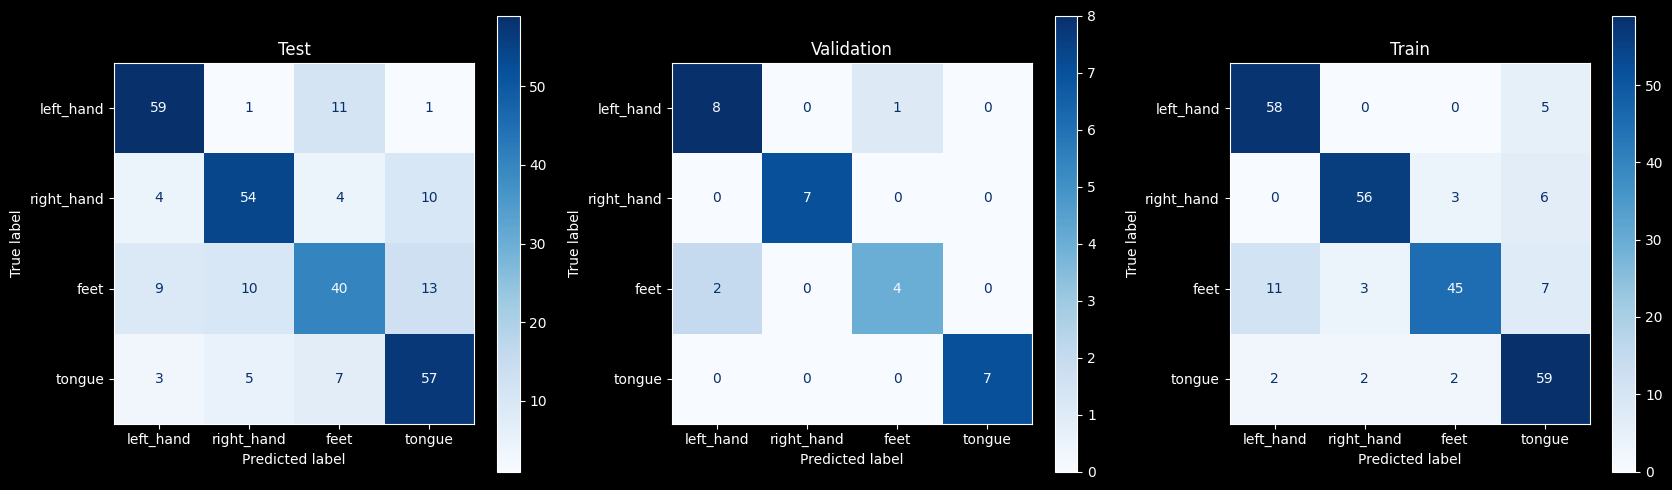

In [ ]:
cm_test = confusion_matrix(labels_test, which_number_is_it)
cm_valid = confusion_matrix(labels_valid, y_pred_valid)
cm_train = confusion_matrix(labels_train, y_pred_train)
#print(cm_test)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=conditions)
disp.plot(cmap='Blues', values_format='d',ax = axes[0])  # 'd' = integer counts [web:3][web:7]
axes[0].set_title('Test')


disp = ConfusionMatrixDisplay(confusion_matrix=cm_valid, display_labels=conditions)
disp.plot(cmap='Blues', values_format='d',ax=axes[1])  # 'd' = integer counts [web:3][web:7]
axes[1].set_title('Validation')


disp = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=conditions)
disp.plot(cmap='Blues', values_format='d',ax=axes[2])  # 'd' = integer counts [web:3][web:7]
axes[2].set_title('Train')

plt.tight_layout()
plt.show()



(22, 1, 8, 2)
(22,)
(22,) type <class 'numpy.ndarray'>
Weights mean contribution:  [0.08302841 0.08385234 0.08263962 0.07169545 0.0830805  0.08576191
 0.07698159 0.08572258 0.07985658 0.09225381 0.07725558 0.09656382
 0.06708631 0.13473804 0.10246098 0.11427389 0.09518954 0.09576689
 0.07289667 0.09599183 0.08432476 0.05765253]


<BarContainer object of 22 artists>

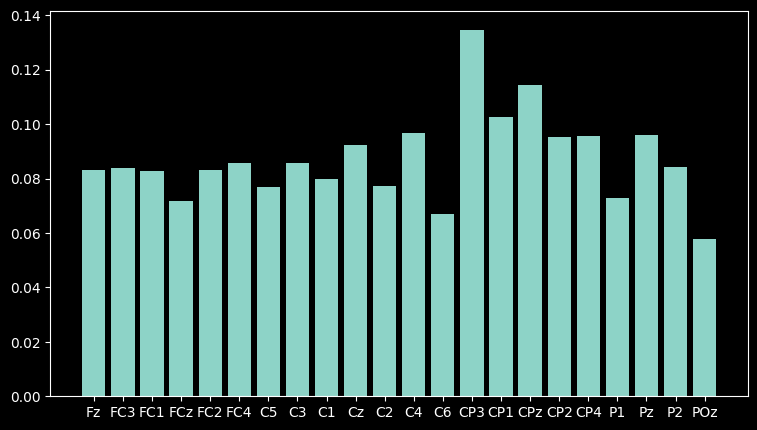

In [ ]:
model = keras.models.load_model('best_mdl.keras')
layers = model.layers # list containing all trained layers
layer = layers [2] # first fully - connected layer
#print(np.size(layer))
weights = layer.get_weights()
weights = np.squeeze(weights, axis=0) # accessing weights and
print(np.shape(weights))
print(np.shape(ch_names))
contribution = np.mean( np.abs(weights) ,2)
contribution = np.mean(contribution,2)
contribution = np.squeeze(contribution, axis=1)
print(np.shape(contribution), 'type', type(contribution))
#print('Weights: ', weights)
print('Weights mean contribution: ', contribution)

plt.figure(figsize=(9,5))
plt.bar(ch_names, contribution)

In [ ]:
idx = random.randint(0, 288-1)

trial = x_test[idx:idx+1, :, :, :]   # shape (1, 28, 28, 1)

# Option 2: start from (28, 28, 1) and add axis
'''
img = x_test[idx, :, :, 0]      # (28, 28)
trial = np.expand_dims(img, axis=0)  # shape (1, 28, 28, 1)

print(trial.shape)

plt.figure()
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()
'''

y_prob_trial = model.predict(trial)
print(y_prob_trial)
y_pred_trial = np.argmax(y_prob_trial)
print(y_pred_trial)
print(conditions[labels_test[idx]])
if y_pred_trial == labels_test[idx]:
  print("The CNN correctly recognized the number! It is a: ", conditions[y_pred_trial])
else:
  print("Nope, it is not a", conditions[y_pred_trial], "! It is a", conditions[labels_test[idx]])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step
[[0.8384674  0.00805991 0.089628   0.06384467]]
0
left_hand
The CNN correctly recognized the number! It is a:  left_hand


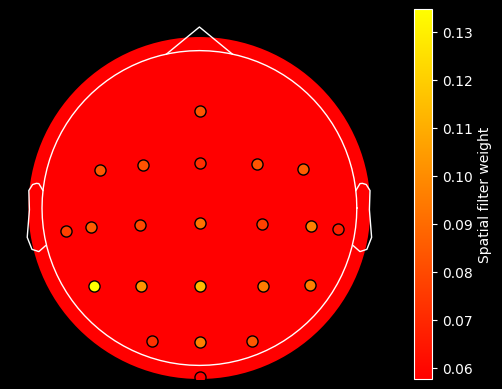

In [ ]:
plot_spatial_filters(contribution, ch_names)